# Sample code for visualization of CPD validation

This is just to give you an idea of what I had in mind.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.random as rnd
import string

In [2]:
sns.set("talk")
sns.set_style("ticks")

In [3]:
# aa position
x = np.arange(-10, 11, 1)
x

array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
         3,   4,   5,   6,   7,   8,   9,  10])

In [4]:
def random_data():
    """
    Generate a random data set where:
    9 = CPD site
    2 = match
    1 = mismatch
    0 = gap
    """
    y = rnd.binomial(n=2, p=.9, size=21)
    y[10] = 9
    return y
random_data()

array([1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 9, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2])

In [5]:
def get_score(data):
    """
    Score the data using the following criteria:
    
    * match: add 5 points
    * gap: subtract 5 points

    Parameters
    ----------
    data : array
        Classification of +/- 10 aa surrounding a CPD. 

    Returns
    -------
    int
        Score.
    """    
    score = 0
    for i in range(21):
        if data[i]==2:
            score += 5
        elif y[i]==0:
            score += -5
    return score

In [6]:
letters = string.ascii_uppercase
def random_name():
    '''Generate a random gene name.'''
    return ''.join(rnd.choice(list(letters), 3)) + str(rnd.randint(1, 20))
random_name()

'DUS8'

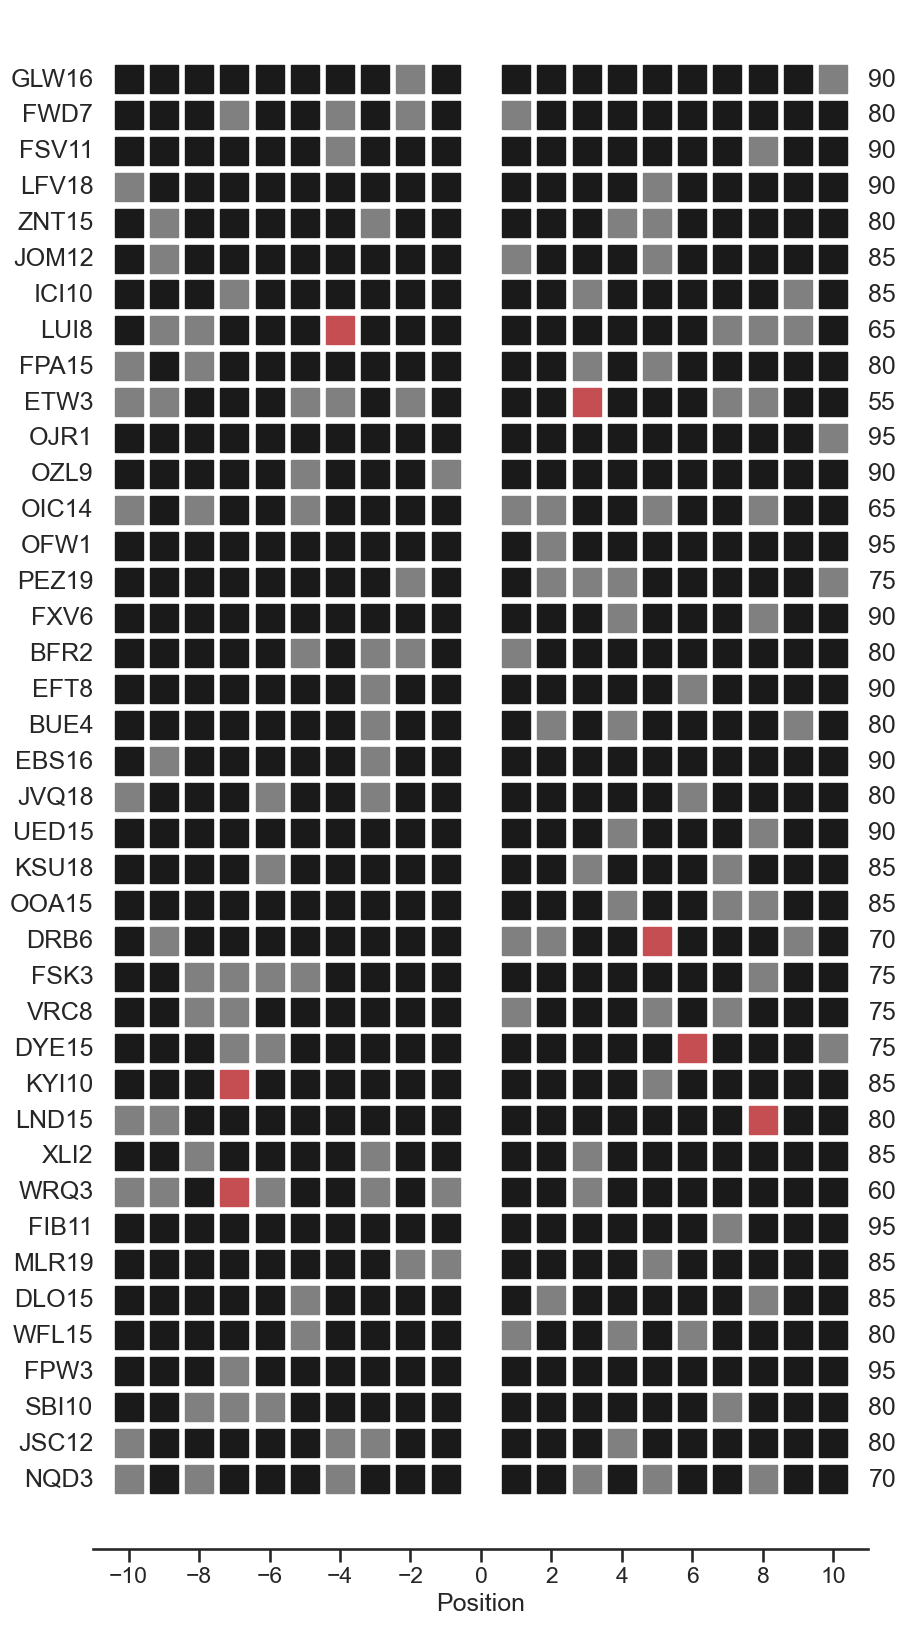

In [7]:
# sample data where matches are 1, mismatches are 0, and gaps are -1; the CPD
# site gets a 9 for clarity
fig, ax = plt.subplots(1, 1, figsize=(10, 20))
for j in range(40):
    y = random_data()
    for i in range(21):
        if x[i]!=0:
            if y[i]==2:
                ax.plot(x[i], [j], 'ks', ms=20)
            elif y[i]==1:
                ax.plot(x[i], [j], 's', color="0.5", ms=20)
            elif y[i]==0:
                ax.plot(x[i], [j], 'rs', ms=20)
    ax.text(-11, j, random_name(), ha='right', va='center')
    ax.text(11, j, str(get_score(y)), ha='left', va='center')
ax.get_yaxis().set_visible(False)
sns.despine(left=True)
ax.set_xticks(np.arange(-10, 11, 2))
ax.set_xlabel('Position')
fig.savefig('validation_viz.pdf')

In [ ]:
!open validation_viz.pdf